# 第一阶段：视觉基础与全链路分类器起步 (MNIST)

欢迎来到硬核实战第一课。本课我们将摒弃碎片化的知识，直接打通真实科研中必经的 **11步全链路流程**。我们将以经典的 MNIST 手写数字识别为例，为你建立工程化的肌肉记忆。

本笔记本严格遵循以下结构：`知识讲解 -> 动机 -> 代码 -> 逐行解析 -> 避坑指南 -> 科研常态 -> 工程建议`。

## 步骤 1-3：数据集准备 ➔ Dataset ➔ DataLoader

### ① 知识讲解
- **Dataset**：负责告诉模型“数据在哪里”以及“如何读取单条数据并进行预处理（如转张量、归一化）”。
- **DataLoader**：负责把单条数据打包成批次（Batch），并提供多线程加速读取（workers）和打乱数据（shuffle）的功能。

### ② 为什么这么做
深度学习模型是靠矩阵运算（GPU并发）吃饭的，一次喂一条数据（Batch Size = 1）极度低效，且梯度更新不稳定。我们必须通过 DataLoader 将其打包成大矩阵批量喂给模型。

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# ③ 完整代码 & ④ 代码逐行解释

# 1. 定义数据预处理流程 (Transforms)
transform = transforms.Compose([
    transforms.ToTensor(), # 将 PIL 图片转为 Tensor，并将像素值从 [0, 255] 缩放到 [0.0, 1.0]
    transforms.Normalize((0.1307,), (0.3081,)) # 使用 MNIST 训练集的全局均值和标准差进行标准化处理
])

# 2. Dataset 准备 (下载并加载数据)
# root='./data' 指定保存路径, train=True 表示这是训练集, download=True 表示没有的话自动下载
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

# 3. DataLoader 打包
batch_size = 64
# shuffle=True 打乱数据防止模型记住顺序; num_workers=0 (在 Mac/Windows 避免多进程报错，Linux下常设为 4 或 8)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"训练集大小: {len(train_dataset)}, 批次数量: {len(train_loader)}")

Matplotlib is building the font cache; this may take a moment.
100%|██████████| 9.91M/9.91M [00:01<00:00, 5.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 346kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.02MB/s]

训练集大小: 60000, 批次数量: 938


### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：在 Mac 上如果 `num_workers > 0` 有时会引发 multiprocessing 的隐蔽报错，卡死在训练第一步。新手排错时，先设为 0；在 `test_loader` 中，切记不要开 `shuffle=True`，不仅没用还拖慢速度。
- **⑥ 科研实验室**：通常不会直接用 `torchvision.datasets` 下载，而是使用公司或实验室积累好的共享数据挂载盘（如 NFS/S3），并在 DataLoader 中编写极度复杂的数据增强逻辑（如 RandomResizedCrop, CutMix）。
- **⑦ 工程实践建议**：工业界读取海量图片时（百万级），小文件读写会把磁盘 I/O 撑爆。常见做法是提前把数据集打包成 LMDB 格式，或使用 WebDataset 顺序读取流式数据。

## 步骤 4：模型搭建 (CNN 网络)

### ① 知识讲解
处理图像特征提取的最优解是卷积神经网络（CNN）。我们将使用 `Conv2d`（二维卷积层）提取局部特征，并用 `Linear`（全连接层）做最终的 10 分类映射。

### ② 为什么这么做
直接用上一课的 MLP 把图片展平成一维向量，会丢失像素在二维空间上的上下左右相邻信息。卷积核像“手电筒”一样扫描全图，完美保留了空间特征。

In [4]:
# ③ 完整代码 & ④ 代码逐行解释
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 卷积层1: 1 个输入通道(灰度图), 32 个输出通道, 卷积核大小 3x3
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # 卷积层2: 32 个通道进，64 个通道出
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # 池化层: 2x2 区域取最大值，将图片长宽缩小一半
        self.pool = nn.MaxPool2d(2, 2)
        # 全连接层1: 经过两次池化后, 28x28 的图变成了 7x7。64 通道 * 7 * 7 = 3136 个特征
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        # 输出层: 映射到 0~9 这 10 个数字分类
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 前向传播数据流向
        x = self.relu(self.conv1(x)) # [Batch, 32, 28, 28]
        x = self.pool(x)             # [Batch, 32, 14, 14]
        
        x = self.relu(self.conv2(x)) # [Batch, 64, 14, 14]
        x = self.pool(x)             # [Batch, 64, 7, 7]
        
        # 核心：将 4 维的卷积输出展平为 2 维的矩阵 [Batch, 64*7*7]
        x = x.view(-1, 64 * 7 * 7)   
        
        x = self.relu(self.fc1(x))   # [Batch, 128]
        x = self.fc2(x)              # [Batch, 10]
        return x

# 初始化模型，并移动到 MPS(GPU) 或 CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = SimpleCNN().to(device)
print(f"模型已加载到: {device}")

模型已加载到: mps


### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：`Linear` 的输入维度（`64 * 7 * 7`）经常算错导致报错 `mat1 and mat2 shapes cannot be multiplied`。笨办法是在 `forward` 里 `print(x.shape)` 看一眼展平前的尺寸。
- **⑥ 科研实验室**：极少自己手写 CNN 结构。科研界都是直接 `import torchvision.models` 加载 ResNet, ConvNeXt 等权威主干网络。
- **⑦ 工程实践建议**：工业落地时，模型大小和推理延迟是红线。工程中会用 MobileNetv3 等轻量级网络代替，或者做量化（INT8）。

## 步骤 5-6：训练 (Train) 与验证 (Eval) 循环

### ① 知识讲解
这是 PyTorch 乃至所有深度学习框架的灵魂代码，千古不变的三大金刚指令。
- **损失函数 (Criterion)**：衡量模型预测有多烂，分类任务必须用交叉熵 `CrossEntropyLoss`。
- **优化器 (Optimizer)**：计算完梯度后，决定以多大步伐（学习率 lr）去修正权重。科研界无脑首选 `AdamW`。

### ② 为什么这么做
模型自己是瞎的，只有通过 Loss 的反向传播（Backward）告诉每个权重参数应该往哪个方向调整一点点，经过几万次的纠错（Step），模型就学会了规律。

In [5]:
# ③ 完整代码 & ④ 代码逐行解释
criterion = nn.CrossEntropyLoss() # 分类任务标配损失函数
optimizer = optim.AdamW(model.parameters(), lr=0.001) # 最先进的优化器
epochs = 2 # 为了快速看到结果，只跑2个Epoch (完整遍历数据集2次)

for epoch in range(epochs):
    # --- 步骤 5: 训练阶段 ---
    model.train() # 必须开启！让 Dropout, BatchNorm 等知道现在是训练状态
    train_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device) # 数据也必须送入 GPU
        
        optimizer.zero_grad() # 金刚指令 1: 清空上一轮残余的梯度
        output = model(data)  # 前向传播，得到预测分数
        loss = criterion(output, target) # 计算预测和真实答案的差距
        
        loss.backward()       # 金刚指令 2: 魔法的反向传播，计算出所有参数的梯度
        optimizer.step()      # 金刚指令 3: 根据梯度，优化器更新一次参数
        
        train_loss += loss.item()
        if batch_idx % 200 == 0:
            print(f"Epoch {epoch+1} [{batch_idx*len(data)}/{len(train_loader.dataset)}] \t Loss: {loss.item():.4f}")

    # --- 步骤 6: 验证阶段 ---
    model.eval() # 必须开启！关闭训练状态特供机制
    correct = 0
    with torch.no_grad(): # 致命坑点：评估时不写这一句会导致显存爆炸（积累了无关梯度）
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            # output 是 [1000, 10] 的矩阵，dim=1 表示在 10 个类别中找最大值所在的索引
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    print(f"====> Epoch {epoch+1} 测试集准确率: {100. * correct / len(test_loader.dataset):.2f}%\n")

Epoch 1 [0/60000] 	 Loss: 2.3038
Epoch 1 [12800/60000] 	 Loss: 0.2660
Epoch 1 [25600/60000] 	 Loss: 0.4176
Epoch 1 [38400/60000] 	 Loss: 0.0923
Epoch 1 [51200/60000] 	 Loss: 0.0810
====> Epoch 1 测试集准确率: 98.49%

Epoch 2 [0/60000] 	 Loss: 0.0553
Epoch 2 [12800/60000] 	 Loss: 0.0551
Epoch 2 [25600/60000] 	 Loss: 0.0160
Epoch 2 [38400/60000] 	 Loss: 0.0686
Epoch 2 [51200/60000] 	 Loss: 0.0127
====> Epoch 2 测试集准确率: 98.86%



### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：忘记 `.to(device)`！模型在 GPU 上，但数据还在 CPU 上，立刻报错。另外，验证时不写 `with torch.no_grad():`，显存很快就会耗尽。
- **⑥ 科研实验室**：没有人会手写这么粗糙的 For 循环。大家都在用 `PyTorch Lightning`、`Accelerate` 或 `Hugging Face Trainer`。只要配置几个参数就能自动搞定分布式训练、半精度(fp16)和日志记录。
- **⑦ 工程实践建议**：训练时必须监控 `Loss` 和 `Accuracy`。工程上强制要求使用 `TensorBoard` 或 `Weights & Biases (WandB)` 记录曲线，绝不只看终端打印输出。

## 步骤 7-10：保存/加载 Checkpoint，推理与可视化

### ① 知识讲解
训练得到的权重参数集合被称为 `state_dict`（状态字典）。我们必须把模型存进硬盘（保存为 `.pth` 文件），否则断电即灰飞烟灭。

### ② 为什么这么做
一次大模型训练可能长达数月，必须要有 checkpointing（存档）机制。万一中断了可以接着训。部署时也只需要加载这个 `.pth` 权重文件即可。

模型参数已保存至 ./mnist_cnn.pth


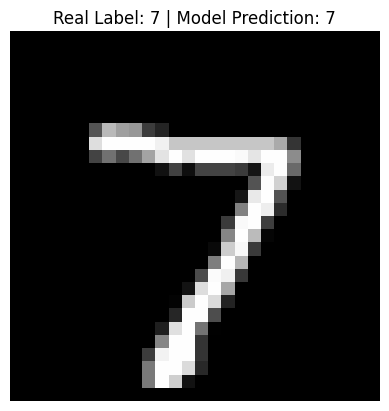

In [6]:
# ③ 完整代码 & ④ 代码逐行解释

# --- 步骤 7: 保存 Checkpoint ---
save_path = "./mnist_cnn.pth"
torch.save(model.state_dict(), save_path) # 只保存权重字典，这是最标准/最安全的方式
print(f"模型参数已保存至 {save_path}")

# --- 步骤 8: 加载 Checkpoint ---
new_model = SimpleCNN().to(device) # 先造一个跟之前一模一样的空壳网络
new_model.load_state_dict(torch.load(save_path)) # 把下载好的灵魂（权重）塞进去
new_model.eval() # 推理前切记切到 eval

# --- 步骤 9 & 10: 推理与可视化 ---
# 从测试集取 1 张图
img, label = test_dataset[0]
img_input = img.unsqueeze(0).to(device) # 原来是 [1,28,28], 必须增加 batch 维度变成 [1,1,28,28]

with torch.no_grad():
    output = new_model(img_input)
    pred = output.argmax(dim=1).item()

# 可视化
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Real Label: {label} | Model Prediction: {pred}")
plt.axis('off')
plt.show()

### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：推理单张图片时，很多人直接把形状为 `[C, H, W]` 的张量扔进模型，立刻报错！模型只认识 `[Batch, C, H, W]`，因此**必须使用 `.unsqueeze(0)` 强行塞入一个 batch 维度**。
- **⑥ 科研实验室**：除了保存 `model.state_dict()`，科研界还会保存 `optimizer.state_dict()` 和 `epoch` 轮数。因为优化器里存了动量等历史信息，光有模型参数是没法完美“断点续传”训练的。
- **⑦ 工程实践建议**：生产环境中保存的名字千万不要只叫 `model.pth`，必须带有唯一的特征标识（比如 `resnet18_epoch50_acc98.pth`）。

## 步骤 11：ONNX 导出与部署建议

### ① 知识讲解与 ② 动机
当我们要把模型装进手机（iOS/Android）、C++ 后端服务器或者自动驾驶芯片上时，直接用 PyTorch 代码是不行的，因为目标平台可能连 Python 环境都没有。

**ONNX (Open Neural Network Exchange)** 是一门世界通用语言。只要把模型翻译成 ONNX，TensorRT、NCNN 等专门的底层推理引擎就能以极限速度运行它。

In [8]:
# ③ 完整代码
dummy_input = torch.randn(1, 1, 28, 28, device=device) # 造一个假输入，让 ONNX 追踪网络流向
onnx_path = "mnist_cnn.onnx"

torch.onnx.export(
    new_model,                 # 要导出的模型
    dummy_input,               # 一个假输入
    onnx_path,                 # 导出的文件名
    export_params=True,        # 顺便把训练好的参数一起塞入文件
    opset_version=11,          # ONNX 的算子集版本
    do_constant_folding=True,  # 优化开关：折叠常量，加快推理
    input_names=['input'],     # 规范输入节点的名字
    output_names=['output'],   # 规范输出节点的名字
    # 支持动态 batch_size，这样推理时就不局限于一次只能传 1 张图了
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"模型已成功导出为标准 ONNX 格式: {onnx_path}")

/var/folders/4x/gykrz2md4nz_j7l5r35_m6880000gn/T/ipykernel_27946/3712810809.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0716 18:14:50.261000 27946 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `SimpleCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/Users/zoupray/miniforge3/envs/llm_env/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/zoupray/miniforge3/envs/llm_env/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/Users/zoupray/miniforge3/envs/llm_env/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/Users/zoupray/miniforge3/envs/llm_env/lib/python3.10/site-packages/onnxscript/ve

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
模型已成功导出为标准 ONNX 格式: mnist_cnn.onnx


### 💡 深度避坑与实践建议
- **⑤ 容易踩坑**：模型如果有 `if-else` 分支逻辑（依赖输入数据动态改变计算图），ONNX 极大概率导出失败。它是静态计算图，只会傻傻记录那一次 `dummy_input` 经过的路径。
- **⑥ 科研实验室**：通常不关心 ONNX，学术论文主要追求精度和方法创新，PyTorch 代码即是尽头。
- **⑦ 工程实践建议 (核心价值)**：这正是高薪算法工程师的立命之本！工业界日常就是：Python 训练 -> 转 ONNX -> 用 TensorRT/Triton Server 在 GPU 加速部署，或者用 NCNN/MNN 在边缘设备上 C++ 推理，推理速度相比原始 PyTorch 通常能提升 3 到 10 倍！

## 🏆 第一阶段结语
恭喜你，你已经用硬核且正确的方式走通了真实科研与工业界的**模型全链路 11 步**。如果你在本地运行顺利通过，请反馈给我，我们将即刻启程进入第二阶段：**如何用真实世界的“猫猫狗狗图片（不规则图片处理）”去训练并微调一个庞大的视觉模型**！